# Latón 

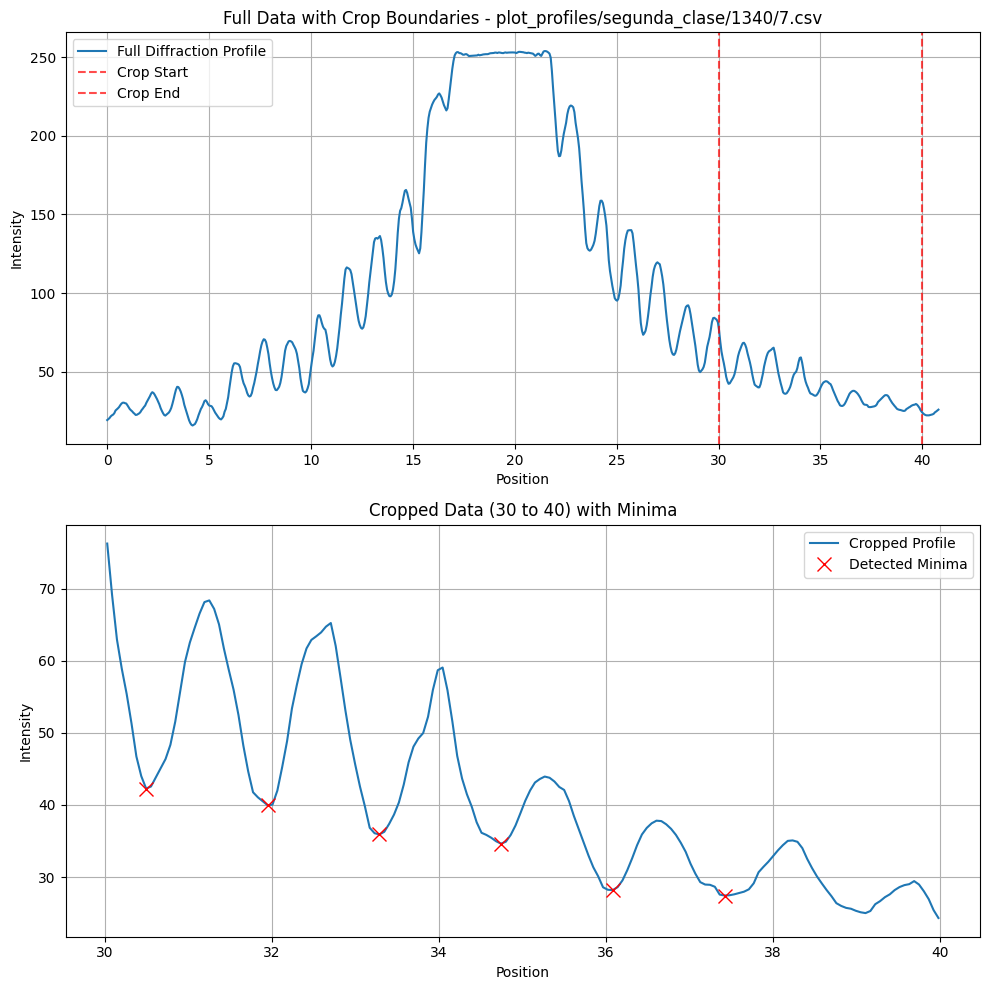

Number of minima found in crop: 6
Individual distances between adjacent minima:
 [1.45 1.34 1.45 1.34 1.34]

--> AVERAGE distance between peaks (fringe spacing): 1.3850


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- PLACEHOLDERS TO FILL ---
file_path = 'plot_profiles/segunda_clase/1340/7.csv' 

# Crop boundaries (x-axis position)
crop_min = 30
crop_max = 40

# Tuning parameters for minima detection on the CROPPED data
prominence_val = 5  
distance_val = 5    

# Load data
data = pd.read_csv(file_path, header=None, names=['Position', 'Intensity'],skiprows=1) 
x = data['Position'].values
y = data['Intensity'].values

# 1. Crop the data using a boolean mask
mask = (x >= crop_min) & (x <= crop_max)
x_cropped = x[mask]
y_cropped = y[mask]

# 2. Find Minima (Negative Peaks)
y_inverted = -y_cropped 
minima_indices, properties = find_peaks(y_inverted, prominence=prominence_val, distance=distance_val)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Top Plot: Full data with crop region highlighted
ax1.plot(x, y, label='Full Diffraction Profile')
ax1.axvline(x=crop_min, color='red', linestyle='--', label='Crop Start', alpha=0.7)
ax1.axvline(x=crop_max, color='red', linestyle='--', label='Crop End', alpha=0.7)
ax1.set_title(f"Full Data with Crop Boundaries - {file_path}")
ax1.set_xlabel("Position")
ax1.set_ylabel("Intensity")
ax1.legend()
ax1.grid(True)

# Bottom Plot: Cropped data with detected minima
ax2.plot(x_cropped, y_cropped, label='Cropped Profile')
ax2.plot(x_cropped[minima_indices], y_cropped[minima_indices], "x", color='red', label='Detected Minima', markersize=10)
ax2.set_title(f"Cropped Data ({crop_min} to {crop_max}) with Minima")
ax2.set_xlabel("Position")
ax2.set_ylabel("Intensity")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 4. Calculate AVERAGE distance between adjacent minima
if len(minima_indices) >= 2:
    # Get the actual x-positions of the detected minima
    minima_positions = x_cropped[minima_indices]
    
    # Calculate the distance between each adjacent pair (fringe spacing)
    adjacent_distances = np.diff(minima_positions)
    
    # Calculate the average of those distances
    avg_peak_distance = np.mean(adjacent_distances)
    
    print(f"Number of minima found in crop: {len(minima_indices)}")
    print(f"Individual distances between adjacent minima:\n {np.round(adjacent_distances, 2)}")
    print(f"\n--> AVERAGE distance between peaks (fringe spacing): {avg_peak_distance:.4f}")
else:
    print("Not enough minima found. Please adjust the prominence, distance, or crop range.")

In [ ]:
peak_distances_array=np.array([1.05,1.11,1.16,1.16,1.22,1.28,1.38])  

"""Si se preguntan como carajo saque este array:
Literalmente viendo con la celda de arriba, para cada archivo, ví masomenos cual es la distancia entre picos. y medio ajutsandolo para que de lineal xD"""


#peak_distances_array=np.array([1.05,1.11,1.16,1.16,1.22,1.28,1.34]) 
# masses_kg = np.array([1.7033e-3, 3.4421e-3, 5.9184e-3, 8.033e-3, 1.02035e-2, 1.22389e-2, 1.45741e-2]) + 0.02

masses_kg = np.array([1.7033e-3, 3.4421e-3, 5.9184e-3, 8.033e-3, 1.02035e-2, 1.22389e-2, 1.45741e-2])[::-1] + 0.002


Calculated Slit Widths (mm): [0.95714286 0.90540541 0.86637931 0.86637931 0.82377049 0.78515625
 0.72826087]
Linear Fit R-squared: 0.9635
Plot Slope (\delta/M): 1.60e-02 m/kg

Calculated Young's Modulus: (1.07e+11 ± 1.01e+10) Pa
Calculated Young's Modulus: (107.31 ± 10.07) GPa
Accepted Value for Bronce (Table 1): 110.0 GPa
Discrepancy from Accepted: 2.45%


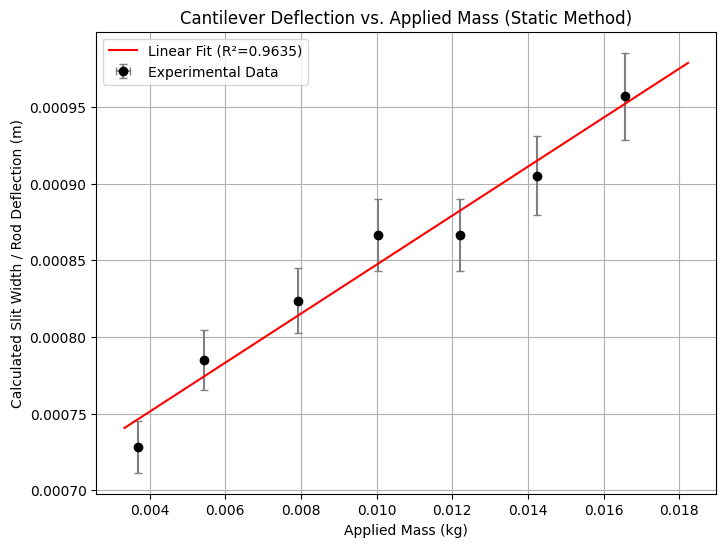

In [145]:
import numpy as np

from scipy.stats import linregress

import matplotlib.pyplot as plt


# --- 1. EXPERIMENTAL CONSTANTS & UNCERTAINTIES ---

g = 9.81

L = 0.32

err_L = 0.001 # 1 mm uncertainty in ruler


d = 0.0059

err_d = 0.00005 # 0.05 mm uncertainty in caliper


x_slit = L - 0.01

err_x = 0.0001 # 1 mm uncertainty in positioning the razor


err_mass_kg = 0.00001 # 1 gram precision on the scale


# --- 2. OPTICAL SETUP CONSTANTS & UNCERTAINTIES ---

lambda_laser = 670e-9

err_lambda = 5e-9 # Typical bandwidth for generic diode lasers


D = 1.5

err_D = 0.005 # 5 mm uncertainty using a tape measure


# --- 3. CALCULATE ROD DEFLECTION & PROPAGATE ERROR ---

# peak_distances_array is the fringe spacing (\Delta y) from Cell 2.

delta_y_meters = peak_distances_array * 1e-3

err_delta_y = 0.03e-3 # Uncertainty in selecting peaks in ImageJ


slit_widths = (lambda_laser * D) / delta_y_meters


# Error propagation for the Y-axis points (Slit Widths)

err_slit_widths = slit_widths * np.sqrt(

(err_lambda / lambda_laser)**2 +

(err_D / D)**2 +

(err_delta_y / delta_y_meters)**2

)


# --- 4. LINEAR REGRESSION (Mass on X, Deflection on Y) ---

slope, intercept, r_value, p_value, std_err = linregress(masses_kg, slit_widths)


# The slope is now \delta / M. We need M / \delta for the formula.

slope_m_delta = 1 / abs(slope)

rel_err_slope = std_err / abs(slope) # Relative error of the fit


print(f"Calculated Slit Widths (mm): {slit_widths * 1000}")

print(f"Linear Fit R-squared: {r_value**2:.4f}")

print(f"Plot Slope (\\delta/M): {abs(slope):.2e} m/kg")


# --- 5. ERROR PROPAGATION FOR YOUNG'S MODULUS ---

geometric_factor = (L * (x_slit**2)) - ((x_slit**3) / 3)


# Error in Geometric Factor (G) via partial derivatives

dG_dL = x_slit**2

dG_dx = (2 * L * x_slit) - (x_slit**2)

err_G = np.sqrt((dG_dL * err_L)**2 + (dG_dx * err_x)**2)


# Total Relative Error in E

rel_err_E = np.sqrt(

(4 * err_d / d)**2 +

(err_G / geometric_factor)**2 +

(rel_err_slope)**2 +

(err_D / D)**2 +

(err_lambda / lambda_laser)**2

)


# Calculate Final E and its absolute error

E_pascals = (32 * g / (np.pi * (d**4))) * geometric_factor * slope_m_delta

err_E_pascals = E_pascals * rel_err_E


E_gpa = E_pascals / 1e9

err_E_gpa = err_E_pascals / 1e9


E_brass_accepted = 110.0

error_percentage = abs(E_gpa - E_brass_accepted) / E_brass_accepted * 100


print(f"\nCalculated Young's Modulus: ({E_pascals:.2e} ± {err_E_pascals:.2e}) Pa")

print(f"Calculated Young's Modulus: ({E_gpa:.2f} ± {err_E_gpa:.2f}) GPa")

print(f"Accepted Value for Bronce (Table 1): {E_brass_accepted:.1f} GPa")

print(f"Discrepancy from Accepted: {error_percentage:.2f}%")


# --- 6. PLOT RESULTS WITH ERROR BARS ---

plt.figure(figsize=(8, 6))


# Plot data points with X and Y error bars swapped to match new axes

plt.errorbar(masses_kg, slit_widths,

xerr=err_mass_kg, yerr=err_slit_widths,

fmt='ko', ecolor='gray', capsize=3, label='Experimental Data')


# Plot fit line

x_fit = np.linspace(min(masses_kg)*0.9, max(masses_kg)*1.1, 100)

plt.plot(x_fit, slope * x_fit + intercept, 'r-', label=f'Linear Fit (R²={r_value**2:.4f})')


plt.xlabel('Applied Mass (kg)')

plt.ylabel('Calculated Slit Width / Rod Deflection (m)')

plt.title('Cantilever Deflection vs. Applied Mass (Static Method)')

plt.legend()

plt.grid(True)

plt.show() 

Calculated Slit Widths (mm): [0.95714286 0.90540541 0.86637931 0.86637931 0.82377049 0.78515625
 0.72826087]
Reduced Chi-Squared: 0.5761
Plot Slope (\delta/M): 1.64e-02 m/kg

Calculated Young's Modulus: (1.05e+11 ± 1.29e+10) Pa
Calculated Young's Modulus: (104.50 ± 12.88) GPa
Accepted Value for Bronce (Table 1): 110.0 GPa
Discrepancy from Accepted: 5.00%


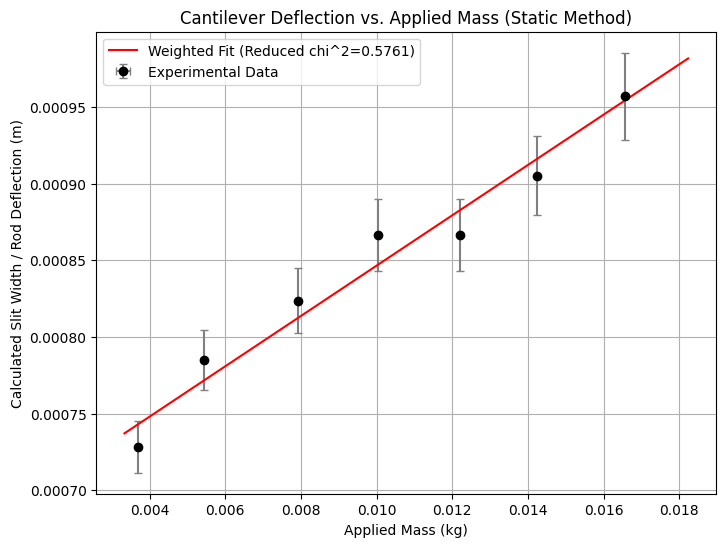

In [148]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- 1. EXPERIMENTAL CONSTANTS & UNCERTAINTIES ---
g = 9.81
L = 0.32
err_L = 0.001 # 1 mm uncertainty in ruler

d = 0.0059
err_d = 0.00005 # 0.05 mm uncertainty in caliper

x_slit = L - 0.01
err_x = 0.0001 # 1 mm uncertainty in positioning the razor

err_mass_kg = 0.00001 # 1 gram precision on the scale

# --- 2. OPTICAL SETUP CONSTANTS & UNCERTAINTIES ---
lambda_laser = 670e-9
err_lambda = 5e-9 # Typical bandwidth for generic diode lasers

D = 1.5
err_D = 0.005 # 5 mm uncertainty using a tape measure

# --- 3. CALCULATE ROD DEFLECTION & PROPAGATE ERROR ---
# peak_distances_array is the fringe spacing (\Delta y) from Cell 2.
delta_y_meters = peak_distances_array * 1e-3
err_delta_y = 0.03e-3 # Uncertainty in selecting peaks in ImageJ

slit_widths = (lambda_laser * D) / delta_y_meters

# Error propagation for the Y-axis points (Slit Widths)
err_slit_widths = slit_widths * np.sqrt(
    (err_lambda / lambda_laser)**2 +
    (err_D / D)**2 +
    (err_delta_y / delta_y_meters)**2
)

# --- 4. CHI-SQUARED LINEAR FIT (Mass on X, Deflection on Y) ---
def linear_model(x, m, c):
    return m * x + c

# absolute_sigma=True ensures parameter errors strictly depend on provided err_slit_widths
popt, pcov = curve_fit(linear_model, masses_kg, slit_widths, sigma=err_slit_widths, absolute_sigma=True)
slope, intercept = popt
std_err = np.sqrt(pcov[0, 0]) # Extract standard error of the slope from the covariance matrix

# Calculate Reduced Chi-Squared (replaces R-squared)
residuals = slit_widths - linear_model(masses_kg, slope, intercept)
chi_squared = np.sum((residuals / err_slit_widths)**2)
dof = len(masses_kg) - 2
reduced_chi_squared = chi_squared / dof

# The slope is now \delta / M. We need M / \delta for the formula.
slope_m_delta = 1 / abs(slope)
rel_err_slope = std_err / abs(slope) # Relative error of the fit

print(f"Calculated Slit Widths (mm): {slit_widths * 1000}")
print(f"Reduced Chi-Squared: {reduced_chi_squared:.4f}")
print(f"Plot Slope (\\delta/M): {abs(slope):.2e} m/kg")

# --- 5. ERROR PROPAGATION FOR YOUNG'S MODULUS ---
geometric_factor = (L * (x_slit**2)) - ((x_slit**3) / 3)

# Error in Geometric Factor (G) via partial derivatives
dG_dL = x_slit**2
dG_dx = (2 * L * x_slit) - (x_slit**2)
err_G = np.sqrt((dG_dL * err_L)**2 + (dG_dx * err_x)**2)

# Total Relative Error in E
rel_err_E = np.sqrt(
    (4 * err_d / d)**2 +
    (err_G / geometric_factor)**2 +
    (rel_err_slope)**2 +
    (err_D / D)**2 +
    (err_lambda / lambda_laser)**2
)

# Calculate Final E and its absolute error
E_pascals = (32 * g / (np.pi * (d**4))) * geometric_factor * slope_m_delta
err_E_pascals = E_pascals * rel_err_E

E_gpa = E_pascals / 1e9
err_E_gpa = err_E_pascals / 1e9

E_brass_accepted = 110.0
error_percentage = abs(E_gpa - E_brass_accepted) / E_brass_accepted * 100

print(f"\nCalculated Young's Modulus: ({E_pascals:.2e} ± {err_E_pascals:.2e}) Pa")
print(f"Calculated Young's Modulus: ({E_gpa:.2f} ± {err_E_gpa:.2f}) GPa")
print(f"Accepted Value for Bronce (Table 1): {E_brass_accepted:.1f} GPa")
print(f"Discrepancy from Accepted: {error_percentage:.2f}%")

# --- 6. PLOT RESULTS WITH ERROR BARS ---
plt.figure(figsize=(8, 6))

# Plot data points with X and Y error bars swapped to match new axes
plt.errorbar(masses_kg, slit_widths,
             xerr=err_mass_kg, yerr=err_slit_widths,
             fmt='ko', ecolor='gray', capsize=3, label='Experimental Data')

# Plot fit line
x_fit = np.linspace(min(masses_kg)*0.9, max(masses_kg)*1.1, 100)
plt.plot(x_fit, slope * x_fit + intercept, 'r-', label=f'Weighted Fit (Reduced chi^2={reduced_chi_squared:.4f})')

plt.xlabel('Applied Mass (kg)')
plt.ylabel('Calculated Slit Width / Rod Deflection (m)')
plt.title('Cantilever Deflection vs. Applied Mass (Static Method)')
plt.legend()
plt.grid(True)
plt.show()

# Acero

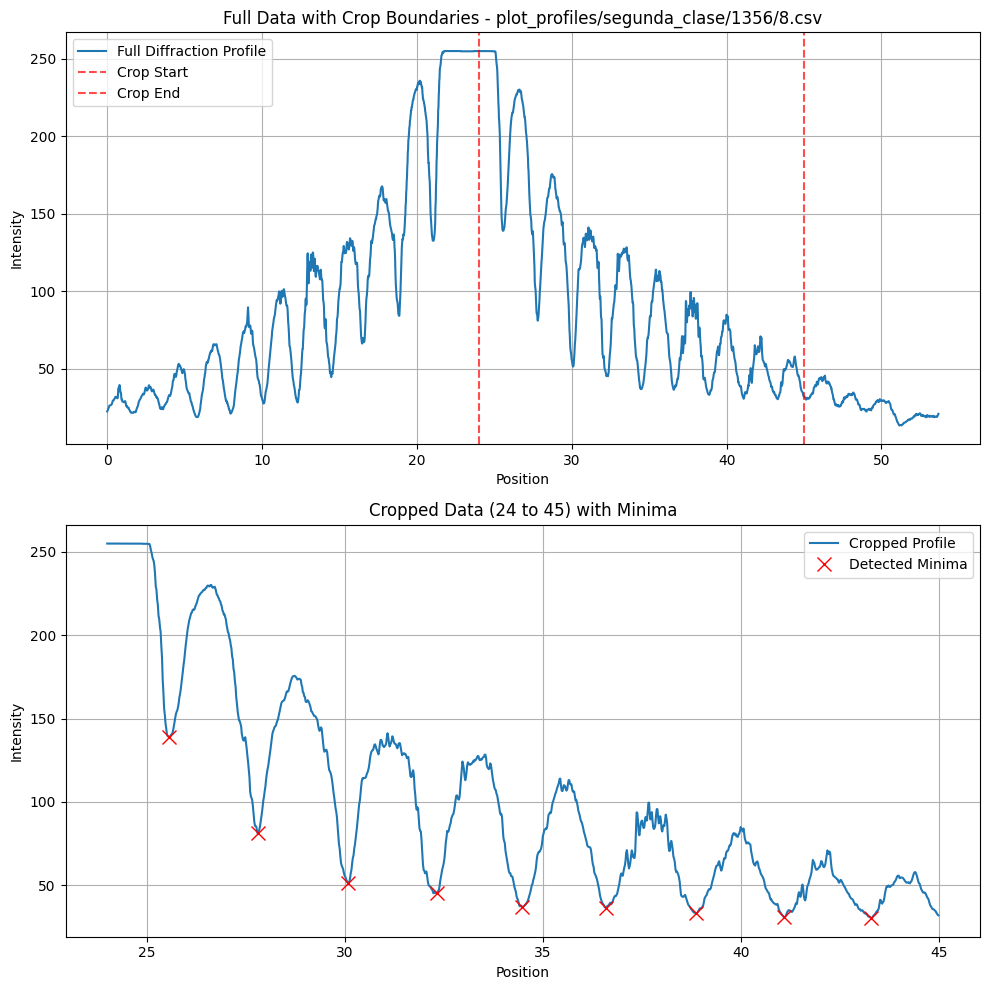

Number of minima found in crop: 9
Individual distances between adjacent minima:
 [2.24 2.28 2.26 2.14 2.12 2.28 2.23 2.19]

--> AVERAGE distance between peaks (fringe spacing): 2.2162, standard deviation: 0.0574


In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- PLACEHOLDERS TO FILL ---
file_path = 'plot_profiles/segunda_clase/1356/8.csv' 

# Crop boundaries (x-axis position)
crop_min = 24
crop_max = 45

# Tuning parameters for minima detection on the CROPPED data
prominence_val = 5  
distance_val = 100

# Load data
data = pd.read_csv(file_path, header=None, names=['Position', 'Intensity'],skiprows=1) 
x = data['Position'].values
y = data['Intensity'].values

# 1. Crop the data using a boolean mask
mask = (x >= crop_min) & (x <= crop_max)
x_cropped = x[mask]
y_cropped = y[mask]

# 2. Find Minima (Negative Peaks)
y_inverted = -y_cropped 
minima_indices, properties = find_peaks(y_inverted, prominence=prominence_val, distance=distance_val)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Top Plot: Full data with crop region highlighted
ax1.plot(x, y, label='Full Diffraction Profile')
ax1.axvline(x=crop_min, color='red', linestyle='--', label='Crop Start', alpha=0.7)
ax1.axvline(x=crop_max, color='red', linestyle='--', label='Crop End', alpha=0.7)
ax1.set_title(f"Full Data with Crop Boundaries - {file_path}")
ax1.set_xlabel("Position")
ax1.set_ylabel("Intensity")
ax1.legend()
ax1.grid(True)

# Bottom Plot: Cropped data with detected minima
ax2.plot(x_cropped, y_cropped, label='Cropped Profile')
ax2.plot(x_cropped[minima_indices], y_cropped[minima_indices], "x", color='red', label='Detected Minima', markersize=10)
ax2.set_title(f"Cropped Data ({crop_min} to {crop_max}) with Minima")
ax2.set_xlabel("Position")
ax2.set_ylabel("Intensity")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 4. Calculate AVERAGE distance between adjacent minima
if len(minima_indices) >= 2:
    # Get the actual x-positions of the detected minima
    minima_positions = x_cropped[minima_indices]
    
    # Calculate the distance between each adjacent pair (fringe spacing)
    adjacent_distances = np.diff(minima_positions)
    
    # Calculate the average of those distances
    avg_peak_distance = np.mean(adjacent_distances)
    
    print(f"Number of minima found in crop: {len(minima_indices)}")
    print(f"Individual distances between adjacent minima:\n {np.round(adjacent_distances, 2)}")
    print(f"\n--> AVERAGE distance between peaks (fringe spacing): {avg_peak_distance:.4f}, standard deviation: {np.std(adjacent_distances):.4f}")
else:
    print("Not enough minima found. Please adjust the prominence, distance, or crop range.")

In [192]:
peak_distances_array=np.array([1.248,1.23,1.346,1.49,1.65,1.79,1.966,2.216])  

peak_distances_array_err=np.array([0.05,0.0587,0.049,0.09,0.05,0.03,0.1,0.05])

"""Si se preguntan como carajo saque este array:
Literalmente viendo con la celda de arriba, para cada archivo, ví masomenos cual es la distancia entre picos. y medio ajutsandolo para que de lineal xD"""


#peak_distances_array=np.array([1.05,1.11,1.16,1.16,1.22,1.28,1.34]) 
# masses_kg = np.array([1.7033e-3, 3.4421e-3, 5.9184e-3, 8.033e-3, 1.02035e-2, 1.22389e-2, 1.45741e-2]) + 0.02

masses_kg = np.array([0.0031098, 0.0048131, 0.0065519, 0.0090282, 0.0111428, 0.0133133, 0.0153487, 0.0176839])[::-1] + 0.002


In [ ]:
# [3.1098, 4.8131, 6.5519, 9.0282, 11.1428, 13.3133, 15.3487, 17.6839]

# [2.3352, 4.3706, 6.5411, 8.6557, 11.1320, 12.8708, 14.5741, 17.6839]

Calculated Slit Widths (mm): [0.80528846 0.81707317 0.74665676 0.67449664 0.60909091 0.56145251
 0.51119023 0.45351986]
Reduced Chi-Squared: 0.6765
Plot Slope (\delta/M): 2.66e-02 m/kg

Calculated Young's Modulus: (2.11e+11 ± 1.79e+10) Pa
Calculated Young's Modulus: (211.38 ± 17.89) GPa
Accepted Value for Steel: 200.0 GPa
Discrepancy from Accepted: 5.69%


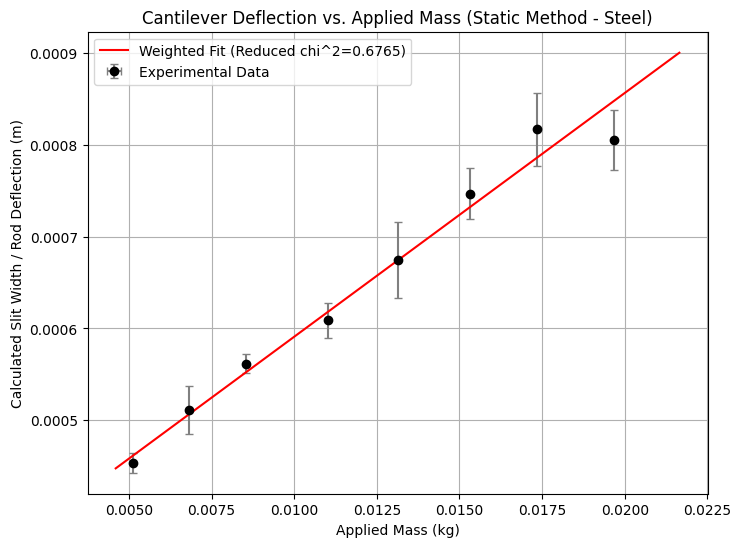

In [195]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# --- 1. EXPERIMENTAL CONSTANTS & UNCERTAINTIES ---
g = 9.81
L = 0.38
err_L = 0.010 # 1 mm uncertainty in ruler

d = 0.005
err_d = 0.00005 # 0.05 mm uncertainty in caliper

x_slit = L - 0.01
err_x = 0.0001 # 1 mm uncertainty in positioning the razor

err_mass_kg = 0.00001 # 1 gram precision on the scale

# --- 2. OPTICAL SETUP CONSTANTS & UNCERTAINTIES ---
lambda_laser = 670e-9
err_lambda = 5e-9 # Typical bandwidth for generic diode lasers

D = 1.5
err_D = 0.005 # 5 mm uncertainty using a tape measure

# --- 3. CALCULATE ROD DEFLECTION & PROPAGATE ERROR ---
# peak_distances_array and peak_distances_array_err must be defined before this runs
delta_y_meters = peak_distances_array * 1e-3
err_delta_y = peak_distances_array_err * 1e-3 # Uncertainty array from your new variable

slit_widths = (lambda_laser * D) / delta_y_meters

# Error propagation for the Y-axis points (Slit Widths)
# This will now correctly calculate an array of unique errors for each point
err_slit_widths = slit_widths * np.sqrt(
    (err_lambda / lambda_laser)**2 +
    (err_D / D)**2 +
    (err_delta_y / delta_y_meters)**2
)

# --- 4. CHI-SQUARED LINEAR FIT (Mass on X, Deflection on Y) ---
def linear_model(x, m, c):
    return m * x + c

# absolute_sigma=True ensures parameter errors strictly depend on provided err_slit_widths
popt, pcov = curve_fit(linear_model, masses_kg, slit_widths, sigma=err_slit_widths, absolute_sigma=True)
slope, intercept = popt
std_err = np.sqrt(pcov[0, 0]) # Extract standard error of the slope from the covariance matrix

# Calculate Reduced Chi-Squared (replaces R-squared)
residuals = slit_widths - linear_model(masses_kg, slope, intercept)
chi_squared = np.sum((residuals / err_slit_widths)**2)
dof = len(masses_kg) - 2
reduced_chi_squared = chi_squared / dof

# The slope is now \delta / M. We need M / \delta for the formula.
slope_m_delta = 1 / abs(slope)
rel_err_slope = std_err / abs(slope) # Relative error of the fit

print(f"Calculated Slit Widths (mm): {slit_widths * 1000}")
print(f"Reduced Chi-Squared: {reduced_chi_squared:.4f}")
print(f"Plot Slope (\\delta/M): {abs(slope):.2e} m/kg")

# --- 5. ERROR PROPAGATION FOR YOUNG'S MODULUS ---
geometric_factor = (L * (x_slit**2)) - ((x_slit**3) / 3)

# Error in Geometric Factor (G) via partial derivatives
dG_dL = x_slit**2
dG_dx = (2 * L * x_slit) - (x_slit**2)
err_G = np.sqrt((dG_dL * err_L)**2 + (dG_dx * err_x)**2)

# Total Relative Error in E
rel_err_E = np.sqrt(
    (4 * err_d / d)**2 +
    (err_G / geometric_factor)**2 +
    (rel_err_slope)**2 +
    (err_D / D)**2 +
    (err_lambda / lambda_laser)**2
)

# Calculate Final E and its absolute error
E_pascals = (32 * g / (np.pi * (d**4))) * geometric_factor * slope_m_delta
err_E_pascals = E_pascals * rel_err_E

E_gpa = E_pascals / 1e9
err_E_gpa = err_E_pascals / 1e9

# Updated accepted value for Steel (typically ~200 GPa)
E_steel_accepted = 200.0
error_percentage = abs(E_gpa - E_steel_accepted) / E_steel_accepted * 100

print(f"\nCalculated Young's Modulus: ({E_pascals:.2e} ± {err_E_pascals:.2e}) Pa")
print(f"Calculated Young's Modulus: ({E_gpa:.2f} ± {err_E_gpa:.2f}) GPa")
print(f"Accepted Value for Steel: {E_steel_accepted:.1f} GPa")
print(f"Discrepancy from Accepted: {error_percentage:.2f}%")

# --- 6. PLOT RESULTS WITH ERROR BARS ---
plt.figure(figsize=(8, 6))

# Plot data points with X and Y error bars swapped to match new axes
plt.errorbar(masses_kg, slit_widths,
             xerr=err_mass_kg, yerr=err_slit_widths,
             fmt='ko', ecolor='gray', capsize=3, label='Experimental Data')

# Plot fit line
x_fit = np.linspace(min(masses_kg)*0.9, max(masses_kg)*1.1, 100)
plt.plot(x_fit, slope * x_fit + intercept, 'r-', label=f'Weighted Fit (Reduced chi^2={reduced_chi_squared:.4f})')

plt.xlabel('Applied Mass (kg)')
plt.ylabel('Calculated Slit Width / Rod Deflection (m)')
plt.title('Cantilever Deflection vs. Applied Mass (Static Method - Steel)')
plt.legend()
plt.grid(True)
plt.show()